# Parkinson’s Disease Detection using Machine Learning and Deep Learning Models

## Problem Overview

Parkinson’s disease is a progressive neurological disorder that affects movement, speech, and motor control. Early and accurate detection is critical for timely intervention and improving patients’ quality of life.

Recent research has shown that vocal impairments—such as variations in frequency, amplitude, and noise—can serve as early biomarkers for Parkinson’s disease. These subtle changes can be captured through sustained phonation recordings and quantified using signal processing techniques.

## Objective

This project aims to develop and evaluate both classical machine learning and deep learning models for Parkinson’s disease detection using voice-based biomedical features.

The key objectives are:

- To build a robust classification model using handcrafted vocal features  
- To compare the performance of machine learning and deep learning approaches  
- To handle class imbalance effectively using weighted loss functions  
- To optimize decision thresholds for improved medical relevance (minimizing false negatives)  

## Approach

Two main approaches are explored:

- **Machine Learning (ML):** Gradient Boosting / XGBoost models trained on structured features  
- **Deep Learning (DL):** FastAI Tabular model using a feedforward neural network architecture  

The deep learning model leverages normalized continuous features and is trained using a multi-layer architecture to capture complex nonlinear relationships within the data.

## Significance

In medical screening tasks, false negatives (missed diagnoses) are more critical than false positives. Therefore, this project emphasizes:

- High recall for Parkinson detection  
- Balanced performance using F1-score and MCC  
- Threshold optimization to align model predictions with clinical priorities  

This work demonstrates how both machine learning and deep learning techniques can be applied effectively to structured biomedical data for early disease detection.

In [1]:
from fastai.tabular.all import *
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

## Dataset Description

The dataset consists of voice signal features extracted from sustained phonation recordings.

- Total samples: 228
- Features: 19 numerical variables
- Target:
  - 0 → Healthy
  - 1 → Parkinson’s disease

The dataset is imbalanced.

In [2]:
df = pd.read_csv(r"D:\Datasets\PD-alldata.csv")
df.head()

,name,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,...,vAm,ATRI,FTRI,DUV,DVB,DSH,VTI,SPI,NHR,status
0,AF_181203_1403.raw,0.6,31,0.3,0.3,0.6,1.3,3.6,0.30,2.1,...,36.2,2.1,0.4,0,0,0,13.71,4.14,27.39,1
1,AF_181203_1610.raw,1.3,60,0.8,0.6,0.9,1.8,10.6,1.06,5.3,...,26.0,6.2,0.6,0,0,0,12.05,5.24,22.47,1
2,AF_181205_1026.raw,1.4,75,0.9,0.7,1.3,2.7,12.7,1.28,6.7,...,39.8,7.6,1.0,0,0,0,11.82,7.56,16.12,1
3,AF_181205_1402.raw,1.0,53,0.6,0.6,0.9,1.3,5.7,0.50,3.5,...,24.5,3.2,0.7,0,0,0,17.71,5.48,16.74,1
4,AF_181205_1426.raw,1.8,90,1.2,0.9,1.2,1.5,9.7,1.17,4.8,...,72.5,4.6,0.9,0,0,0,13.93,3.94,24.29,1


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (228, 21)

Columns:
['name', 'jitt', 'jita', 'RAP', 'PPQ', 'sPPQ', 'vfo', 'shim', 'shdb', 'APQ', 'sAPQ', 'vAm', 'ATRI', 'FTRI', 'DUV', 'DVB', 'DSH', 'VTI', 'SPI', 'NHR', 'status']


In [4]:
df.dtypes

name       object
jitt      float64
jita        int64
RAP       float64
PPQ       float64
sPPQ      float64
vfo       float64
shim      float64
shdb      float64
APQ       float64
sAPQ      float64
vAm       float64
ATRI      float64
FTRI      float64
DUV         int64
DVB         int64
DSH         int64
VTI       float64
SPI       float64
NHR       float64
status      int64
dtype: object

In [5]:
df.isnull().sum()

name      0
jitt      0
jita      0
RAP       0
PPQ       0
sPPQ      0
vfo       0
shim      0
shdb      0
APQ       0
sAPQ      0
vAm       0
ATRI      0
FTRI      0
DUV       0
DVB       0
DSH       0
VTI       0
SPI       0
NHR       0
status    0
dtype: int64

In [6]:
print(df["status"].value_counts())
print("\nNormalized:")
print(df["status"].value_counts(normalize=True))

status
1    187
0     41
Name: count, dtype: int64

Normalized:
status
1    0.820175
0    0.179825
Name: proportion, dtype: float64


## Feature Description

The features include:

- Jitter: frequency variation
- Shimmer: amplitude variation
- Noise measures (NHR)
- Voice stability indicators (RAP, PPQ, APQ)

These capture vocal irregularities related to Parkinson’s disease.

In [7]:
target = "status"

cont_names = [
    "jitt", "jita", "RAP", "PPQ", "sPPQ", "vfo",
    "shim", "shdb", "APQ", "sAPQ", "vAm",
    "ATRI", "FTRI", "DUV", "DVB", "DSH",
    "VTI", "SPI", "NHR"
]

cat_names = []

In [8]:
df_model = df[cont_names + [target]].copy()
df_model.head()

,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,sAPQ,vAm,ATRI,FTRI,DUV,DVB,DSH,VTI,SPI,NHR,status
0,0.6,31,0.3,0.3,0.6,1.3,3.6,0.30,2.1,4.2,36.2,2.1,0.4,0,0,0,13.71,4.14,27.39,1
1,1.3,60,0.8,0.6,0.9,1.8,10.6,1.06,5.3,8.0,26.0,6.2,0.6,0,0,0,12.05,5.24,22.47,1
2,1.4,75,0.9,0.7,1.3,2.7,12.7,1.28,6.7,15.0,39.8,7.6,1.0,0,0,0,11.82,7.56,16.12,1
3,1.0,53,0.6,0.6,0.9,1.3,5.7,0.50,3.5,6.5,24.5,3.2,0.7,0,0,0,17.71,5.48,16.74,1
4,1.8,90,1.2,0.9,1.2,1.5,9.7,1.17,4.8,9.3,72.5,4.6,0.9,0,0,0,13.93,3.94,24.29,1


In [9]:
df_model[target] = df_model[target].astype(str)
df_model[target].value_counts()

status
1    187
0     41
Name: count, dtype: int64

In [10]:
train_idx, valid_idx = train_test_split(
    range(len(df_model)),
    test_size=0.2,
    random_state=42,
    stratify=df_model[target]
)

print("Train size:", len(train_idx))
print("Valid size:", len(valid_idx))

Train size: 182
Valid size: 46


## Methodology (FastAI Tabular)

A FastAI Tabular model is used to learn patterns from structured data.

- Features are normalized
- No categorical variables
- 80/20 validation split
- Neural network: [256, 128, 64]

In [11]:
procs = [Normalize]

dls = TabularDataLoaders.from_df(
    df_model,
    procs=procs,
    cat_names=cat_names,
    cont_names=cont_names,
    y_names=target,
    valid_idx=list(valid_idx),
    bs=64
)

In [12]:
dls.show_batch()

,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,sAPQ,vAm,ATRI,FTRI,DUV,DVB,DSH,VTI,SPI,NHR,status
0,1.1,106.999999,0.6,0.7,0.8,1.2,9.0,1.10,5.9,9.7,37.200001,1.0,0.7,0.0,0.0,0.0,4.62,23.18,4.390000,1
1,0.7,72.000009,0.4,0.4,0.8,1.0,8.3,0.71,5.2,7.0,16.799999,5.5,0.4,0.0,0.0,0.0,4.22,10.38,7.490000,0
2,0.2,25.999995,0.1,0.1,0.5,1.4,2.7,0.23,1.7,3.3,21.000000,26.1,0.3,0.0,0.0,0.0,17.28,2.71,28.380000,1
3,0.4,30.999995,0.2,0.2,0.6,2.8,2.8,0.24,1.7,4.5,37.000000,3.7,0.3,0.0,0.0,0.0,5.04,7.74,13.610000,1
4,0.3,22.000008,0.2,0.2,0.7,1.4,2.8,0.25,1.8,4.1,15.100000,3.5,0.4,0.0,0.0,0.0,8.47,6.50,14.180000,1
5,13.3,2305.999925,8.6,10.7,11.8,13.9,5.2,0.50,3.6,7.3,26.200001,2.2,9.8,0.0,0.0,0.0,4.20,21.18,4.890000,1
6,0.7,38.999991,0.4,0.4,0.5,0.5,4.9,0.43,2.9,4.9,6.700000,3.4,0.3,0.0,0.0,0.0,9.31,9.26,10.030000,0
7,0.3,23.999991,0.2,0.2,0.5,1.5,4.0,0.34,2.3,5.1,23.100000,2.5,0.4,0.0,0.0,0.0,19.28,2.67,29.360001,1
8,0.4,35.999995,0.2,0.3,0.5,0.8,4.0,0.35,2.7,4.3,6.700000,2.8,0.3,0.0,0.0,0.0,3.92,8.63,9.580000,0
9,0.4,68.999992,0.1,0.2,0.6,1.4,4.0,0.34,2.8,3.8,11.800001,0.3,0.3,0.0,0.0,0.0,10.77,6.62,13.580000,1


In [13]:
learn = tabular_learner(
    dls,
    layers=[256, 128, 64],
    metrics=[accuracy, RocAucBinary()]
)

<div></div>

SuggestedLRs(valley=0.0008317637839354575)

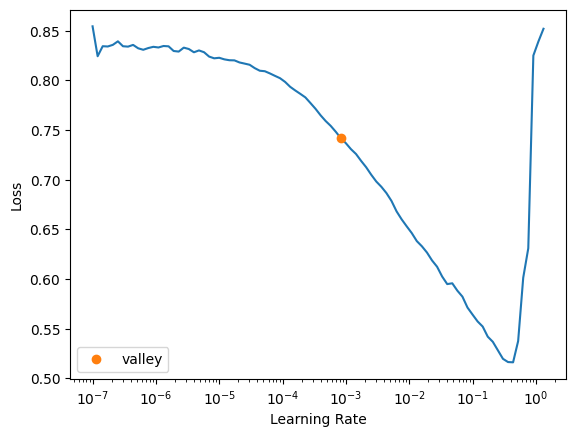

In [14]:
learn.lr_find()

In [15]:
learn.fit_one_cycle(50, 1e-3)

epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,0.778862,0.707222,0.260870,0.404605,00:00
1,0.777678,0.741568,0.217391,0.414474,00:00
2,0.784861,0.774919,0.195652,0.430921,00:00
3,0.754997,0.803327,0.195652,0.608553,00:00
4,0.734303,0.825119,0.195652,0.845395,00:00
5,0.716124,0.843710,0.173913,0.911184,00:00
6,0.687714,0.853273,0.173913,0.944079,00:00
7,0.671511,0.851437,0.173913,0.944079,00:00
8,0.647155,0.843344,0.173913,0.947368,00:00
9,0.633891,0.831899,0.195652,0.940789,00:00


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

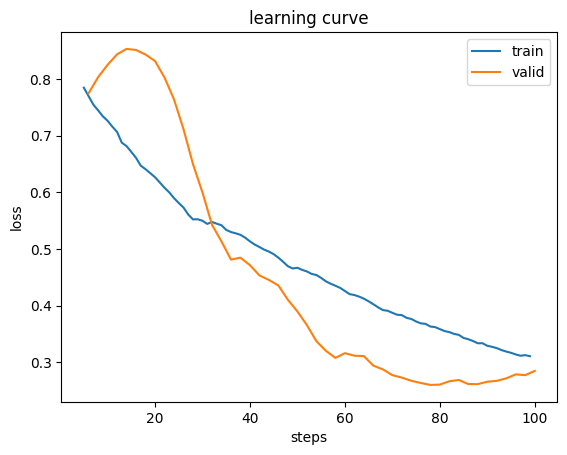

In [16]:
learn.recorder.plot_loss()

In [17]:
preds, targs = learn.get_preds()

print(preds.shape) 

pred_probs = preds[:, 1].numpy()
pred_labels = preds.argmax(dim=1).numpy()
true_labels = targs.numpy()

torch.Size([46, 2])


In [18]:
acc = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, zero_division=0)
rec = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)
roc = roc_auc_score(true_labels, pred_probs)
mcc = matthews_corrcoef(true_labels, pred_labels)

print("Baseline Accuracy :", round(acc, 4))
print("Baseline Precision:", round(prec, 4))
print("Baseline Recall   :", round(rec, 4))
print("Baseline F1-score :", round(f1, 4))
print("Baseline ROC-AUC  :", round(roc, 4))
print("Baseline MCC      :", round(mcc, 4))

Baseline Accuracy : 0.913
Baseline Precision: 1.0
Baseline Recall   : 0.8947
Baseline F1-score : 0.9444
Baseline ROC-AUC  : 0.9934
Baseline MCC      : 0.7723


In [19]:
print(confusion_matrix(true_labels, pred_labels))
print()
print(classification_report(true_labels, pred_labels, zero_division=0))

[[ 8  0]
 [ 4 34]]

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           1       1.00      0.89      0.94        38

    accuracy                           0.91        46
   macro avg       0.83      0.95      0.87        46
weighted avg       0.94      0.91      0.92        46



## Handling Class Imbalance

The dataset is imbalanced.

To address this, class weights are applied:
- Minority class gets higher penalty
- Improves Parkinson detection performance

In [20]:
class_counts = df_model[target].value_counts().sort_index()
print(class_counts)

status
0     41
1    187
Name: count, dtype: int64


In [21]:
import torch
from fastai.losses import CrossEntropyLossFlat

class_weights = torch.tensor(
    [len(df_model) / (2 * class_counts[i]) for i in class_counts.index],
    dtype=torch.float32
).to(dls.device)

print(class_weights)

tensor([2.7805, 0.6096])


In [22]:
loss_func_w = CrossEntropyLossFlat(weight=class_weights)

In [23]:
learn_w = tabular_learner(
    dls,
    layers=[256, 128, 64],
    loss_func=loss_func_w,
    metrics=[accuracy, RocAucBinary()]
)

<div></div>

SuggestedLRs(valley=0.004365158267319202)

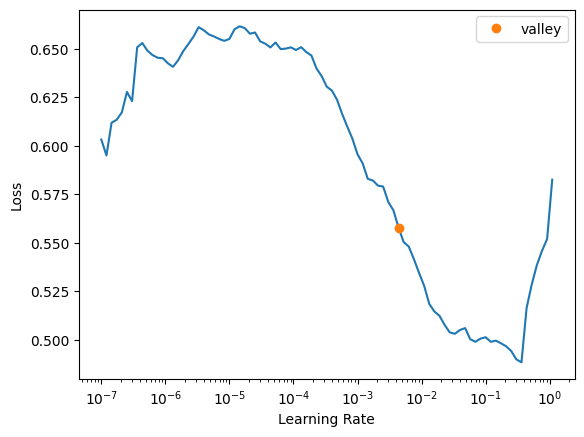

In [24]:
learn_w.lr_find()

In [25]:
learn_w.fit_one_cycle(50, 1e-3)

epoch,train_loss,valid_loss,accuracy,roc_auc_score,time
0,0.651027,0.693261,0.217391,0.394737,00:00
1,0.694876,0.693294,0.217391,0.411184,00:00
2,0.668947,0.691165,0.239130,0.493421,00:00
3,0.646042,0.685027,0.282609,0.687500,00:00
4,0.620387,0.674699,0.282609,0.815789,00:00
5,0.604037,0.663025,0.282609,0.868421,00:00
6,0.579458,0.645875,0.282609,0.911184,00:00
7,0.558798,0.626834,0.347826,0.934211,00:00
8,0.544013,0.605534,0.456522,0.947368,00:00
9,0.544895,0.589431,0.521739,0.940789,00:00


In [26]:
preds_w, targs_w = learn_w.get_preds()

print(preds_w.shape)

torch.Size([46, 2])


In [27]:
pred_probs_w = preds_w[:, 1].numpy()
pred_labels_w = preds_w.argmax(dim=1).numpy()
true_labels_w = targs_w.numpy()

In [28]:
acc_w = accuracy_score(true_labels_w, pred_labels_w)
prec_w = precision_score(true_labels_w, pred_labels_w, zero_division=0)
rec_w = recall_score(true_labels_w, pred_labels_w, zero_division=0)
f1_w = f1_score(true_labels_w, pred_labels_w, zero_division=0)
roc_w = roc_auc_score(true_labels_w, pred_probs_w)
mcc_w = matthews_corrcoef(true_labels_w, pred_labels_w)

print("Weighted Accuracy :", round(acc_w, 4))
print("Weighted Precision:", round(prec_w, 4))
print("Weighted Recall   :", round(rec_w, 4))
print("Weighted F1-score :", round(f1_w, 4))
print("Weighted ROC-AUC  :", round(roc_w, 4))
print("Weighted MCC      :", round(mcc_w, 4))

Weighted Accuracy : 0.8261
Weighted Precision: 1.0
Weighted Recall   : 0.7895
Weighted F1-score : 0.8824
Weighted ROC-AUC  : 0.9901
Weighted MCC      : 0.6283


In [29]:
print(confusion_matrix(true_labels_w, pred_labels_w))
print()
print(classification_report(true_labels_w, pred_labels_w, zero_division=0))

[[ 8  0]
 [ 8 30]]

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         8
           1       1.00      0.79      0.88        38

    accuracy                           0.83        46
   macro avg       0.75      0.89      0.77        46
weighted avg       0.91      0.83      0.84        46



## Threshold Optimization

Default threshold is 0.5.

In medical applications, false negatives are critical.

We optimize the threshold to improve recall.

In [30]:
thresholds = np.linspace(0.1, 0.9, 81)

best_th = 0
best_recall = 0

for th in thresholds:
    preds_th = (pred_probs_w >= th).astype(int)

    rec = recall_score(true_labels_w, preds_th, zero_division=0)

    if rec > best_recall:
        best_recall = rec
        best_th = th

print("Best Threshold:", round(best_th, 3))
print("Best Recall:", round(best_recall, 4))

Best Threshold: 0.1
Best Recall: 0.9737


In [31]:
final_preds = (pred_probs_w >= best_th).astype(int)

print(confusion_matrix(true_labels_w, final_preds))
print()
print(classification_report(true_labels_w, final_preds, zero_division=0))
print("Final MCC:", round(matthews_corrcoef(true_labels_w, final_preds), 4))

[[ 7  1]
 [ 1 37]]

              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.97      0.97      0.97        38

    accuracy                           0.96        46
   macro avg       0.92      0.92      0.92        46
weighted avg       0.96      0.96      0.96        46

Final MCC: 0.8487


In [32]:
import os
print(os.getcwd())

D:\parkinsons-fastai\notebooks


In [33]:
best_threshold = best_th

final_acc = accuracy_score(true_labels_w, final_preds)
final_prec = precision_score(true_labels_w, final_preds, zero_division=0)
final_rec = recall_score(true_labels_w, final_preds, zero_division=0)
final_f1 = f1_score(true_labels_w, final_preds, zero_division=0)
final_roc = roc_auc_score(true_labels_w, pred_probs_w)
final_mcc = matthews_corrcoef(true_labels_w, final_preds)

print("Final Accuracy :", round(final_acc, 4))
print("Final Precision:", round(final_prec, 4))
print("Final Recall   :", round(final_rec, 4))
print("Final F1-score :", round(final_f1, 4))
print("Final ROC-AUC  :", round(final_roc, 4))
print("Final MCC      :", round(final_mcc, 4))
print("Best Threshold :", round(best_threshold, 4))

Final Accuracy : 0.9565
Final Precision: 0.9737
Final Recall   : 0.9737
Final F1-score : 0.9737
Final ROC-AUC  : 0.9901
Final MCC      : 0.8487
Best Threshold : 0.1


In [34]:
comparison_df = pd.DataFrame([
    {
        "model": "Weighted (default threshold=0.5)",
        "accuracy": acc_w,
        "precision": prec_w,
        "recall": rec_w,
        "f1_score": f1_w,
        "roc_auc": roc_w,
        "mcc": mcc_w
    },
    {
        "model": f"Weighted + tuned threshold ({best_threshold:.2f})",
        "accuracy": final_acc,
        "precision": final_prec,
        "recall": final_rec,
        "f1_score": final_f1,
        "roc_auc": final_roc,
        "mcc": final_mcc
    }
])

comparison_df.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc,mcc
0,Weighted (default threshold=0.5),0.8261,1.0000,0.7895,0.8824,0.9901,0.6283
1,Weighted + tuned threshold (0.10),0.9565,0.9737,0.9737,0.9737,0.9901,0.8487


In [35]:
comparison_df.to_csv("../models/fastai_model_comparison.csv", index=False)
print("Saved to ../models/fastai_model_comparison.csv")

Saved to ../models/fastai_model_comparison.csv


## Conclusion

The FastAI Tabular model achieved strong performance in Parkinson’s detection.

Key improvements:
- Weighted loss to handle imbalance
- Threshold tuning (best = 0.10)

Final performance:
- Accuracy: 0.9565
- Recall: 0.9737
- F1-score: 0.9737
- ROC-AUC: 0.9901
- MCC: 0.8487

The model achieved high recall while maintaining strong overall performance.

Note: Results are based on a single validation split.